# Восстановление изображений из атакованных латентных векторов

Этот ноутбук:
1. Загружает обученный VAE-декодер
2. Декодирует **оригинальные** латентные векторы (из `data_for_attack.csv`)
3. Декодирует **атакованные** латентные векторы (из `adversarial_samples.json`)
4. Сравнивает результаты: оригинал vs атака

**Необходимо:** файл `checkpoint_*.pth` в папке `PIPELINE/model/`

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn

from PIL import Image, ImageFilter, ImageEnhance

In [ ]:
# Пути
root = Path('..').resolve()
input_csv = root / 'data' / 'data_for_attack.csv'
adv_json = root / 'results' / 'samples' / 'adversarial_samples.json'
# checkpoint_path = root / 'model' / 'checkpoint_vae_final.pth'
checkpoint_path = root / 'model' / 'checkpoint_vae_[MOD].pth'

print(f'Root: {root}')
print(f'Checkpoint exists: {checkpoint_path.exists()}')
print(f'Input CSV exists: {input_csv.exists()}')
print(f'Adversarial JSON exists: {adv_json.exists()}')

Root: C:\Users\sukharev\Desktop\maga\diplom\NCT-research\PIPELINE
Checkpoint exists: True
Input CSV exists: True
Adversarial JSON exists: True


In [39]:
# # Определение VAE (та же архитектура, что и при обучении)
# class VAE(nn.Module):
#     def __init__(self, latent_dim=512):
#         super(VAE, self).__init__()
#         self.latent_dim = latent_dim

#         # Encoder
#         self.encoder = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#         )

#         self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
#         self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

#         self.fc_decode = nn.Linear(latent_dim, 128 * 8 * 8)

#         # Decoder
#         self.decoder = nn.Sequential(
#             nn.ConvTranspose2d(128, 128, 3, 2, 1, output_padding=1),
#             nn.ReLU(),

#             nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),
#             nn.ReLU(),

#             nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
#             nn.ReLU(),

#             nn.ConvTranspose2d(32, 3, 3, 2, 1, output_padding=1),
#             nn.Sigmoid()
#         )

#     def encode(self, x):
#         h = self.encoder(x)
#         h = h.view(h.size(0), -1)
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar

#     def reparameterize(self, mu, logvar):
#         std = torch.exp(0.5 * logvar)
#         eps = torch.randn_like(std)
#         return mu + eps * std

#     def decode(self, z):
#         h = self.fc_decode(z)
#         h = h.view(h.size(0), 128, 8, 8)
#         return self.decoder(h)

#     def forward(self, x):
#         mu, logvar = self.encode(x)
#         z = self.reparameterize(mu, logvar)
#         x_recon = self.decode(z)
#         return x_recon, z, mu, logvar

In [4]:
# новый модифицированный VAE
class VAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder: 128→64→32→16→8
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2),                # 128→64

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2),                # 64→32

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2),                # 32→16

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2),                # 16→8
        )

        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)

        # Decoder: 8→16→32→64→128
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, 4, 2, 1),  # 8→16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16→32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32→64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 64→128
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = torch.clamp(self.fc_logvar(h), min=-10, max=10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), z, mu, logvar

    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim).to(device)
        return self.decode(z)


In [5]:
# Загрузка модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = VAE(latent_dim=512)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Убираем префикс 'module.' если модель была обернута в DataParallel
state_dict = checkpoint['model_state_dict']
new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace('module.', '') if k.startswith('module.') else k
    new_state_dict[new_key] = v

model.load_state_dict(new_state_dict)
model.to(device)
model.eval()
print('VAE модель загружена')

Device: cpu
VAE модель загружена


In [6]:
# Загрузка оригинальных признаков
input_df = pd.read_csv(input_csv)
feature_cols = [c for c in input_df.columns if c.startswith('f')]
print(f'Оригинальных образцов: {len(input_df)}, признаков: {len(feature_cols)}')

# Загрузка атакованных признаков
with open(adv_json, 'r', encoding='utf-8') as f:
    adv_data = json.load(f)

adv_samples = adv_data['samples']
print(f'Атакованных образцов: {len(adv_samples)}')

Оригинальных образцов: 5, признаков: 512
Атакованных образцов: 5


In [7]:
# Подготовка пар: оригинал и атакованный вектор
input_by_id = input_df.set_index('id')

pairs = []
for sample in adv_samples:
    sample_id = sample['id']
    true_class = sample['true_class']
    adv_features = np.array(sample['features'])
    orig_features = input_by_id.loc[sample_id, feature_cols].to_numpy(dtype=float)
    pairs.append({
        'id': sample_id,
        'class': true_class,
        'orig': orig_features,
        'adv': adv_features
    })

print(f'Подготовлено пар для сравнения: {len(pairs)}')

Подготовлено пар для сравнения: 5


In [8]:
def enhance_image(img_np, upscale=4, sharpen=1.5, contrast=1.3, color=1.2):
    """
    Постобработка: апскейл, резкость, контраст, насыщенность.
    img_np: numpy HWC float [0,1]
    """
    img_uint8 = (img_np * 255).astype(np.uint8)
    pil_img = Image.fromarray(img_uint8)
    
    # Апскейл через бикубическую интерполяцию (128x128 -> 512x512)
    w, h = pil_img.size
    pil_img = pil_img.resize((w * upscale, h * upscale), Image.LANCZOS)
    
    # Резкость
    pil_img = ImageEnhance.Sharpness(pil_img).enhance(sharpen)
    
    # Контраст
    pil_img = ImageEnhance.Contrast(pil_img).enhance(contrast)
    
    # Насыщенность цвета
    pil_img = ImageEnhance.Color(pil_img).enhance(color)
    
    return np.array(pil_img).astype(np.float32) / 255.0


def decode_and_enhance(model, z_numpy, device, **enhance_kwargs):
    """Декодирует и улучшает изображение"""
    img = decode_latent(model, z_numpy, device)
    return enhance_image(img, **enhance_kwargs)

In [9]:
# Функция декодирования латентного вектора в изображение
def decode_latent(model, z_numpy, device):
    """Декодирует латентный вектор (numpy) в изображение (numpy HWC)"""
    with torch.no_grad():
        z = torch.tensor(z_numpy, dtype=torch.float32).unsqueeze(0).to(device)
        img = model.decode(z)
        img = img.squeeze(0).cpu().numpy()
        img = np.transpose(img, (1, 2, 0))  # CHW -> HWC
        img = np.clip(img, 0, 1)
    return img

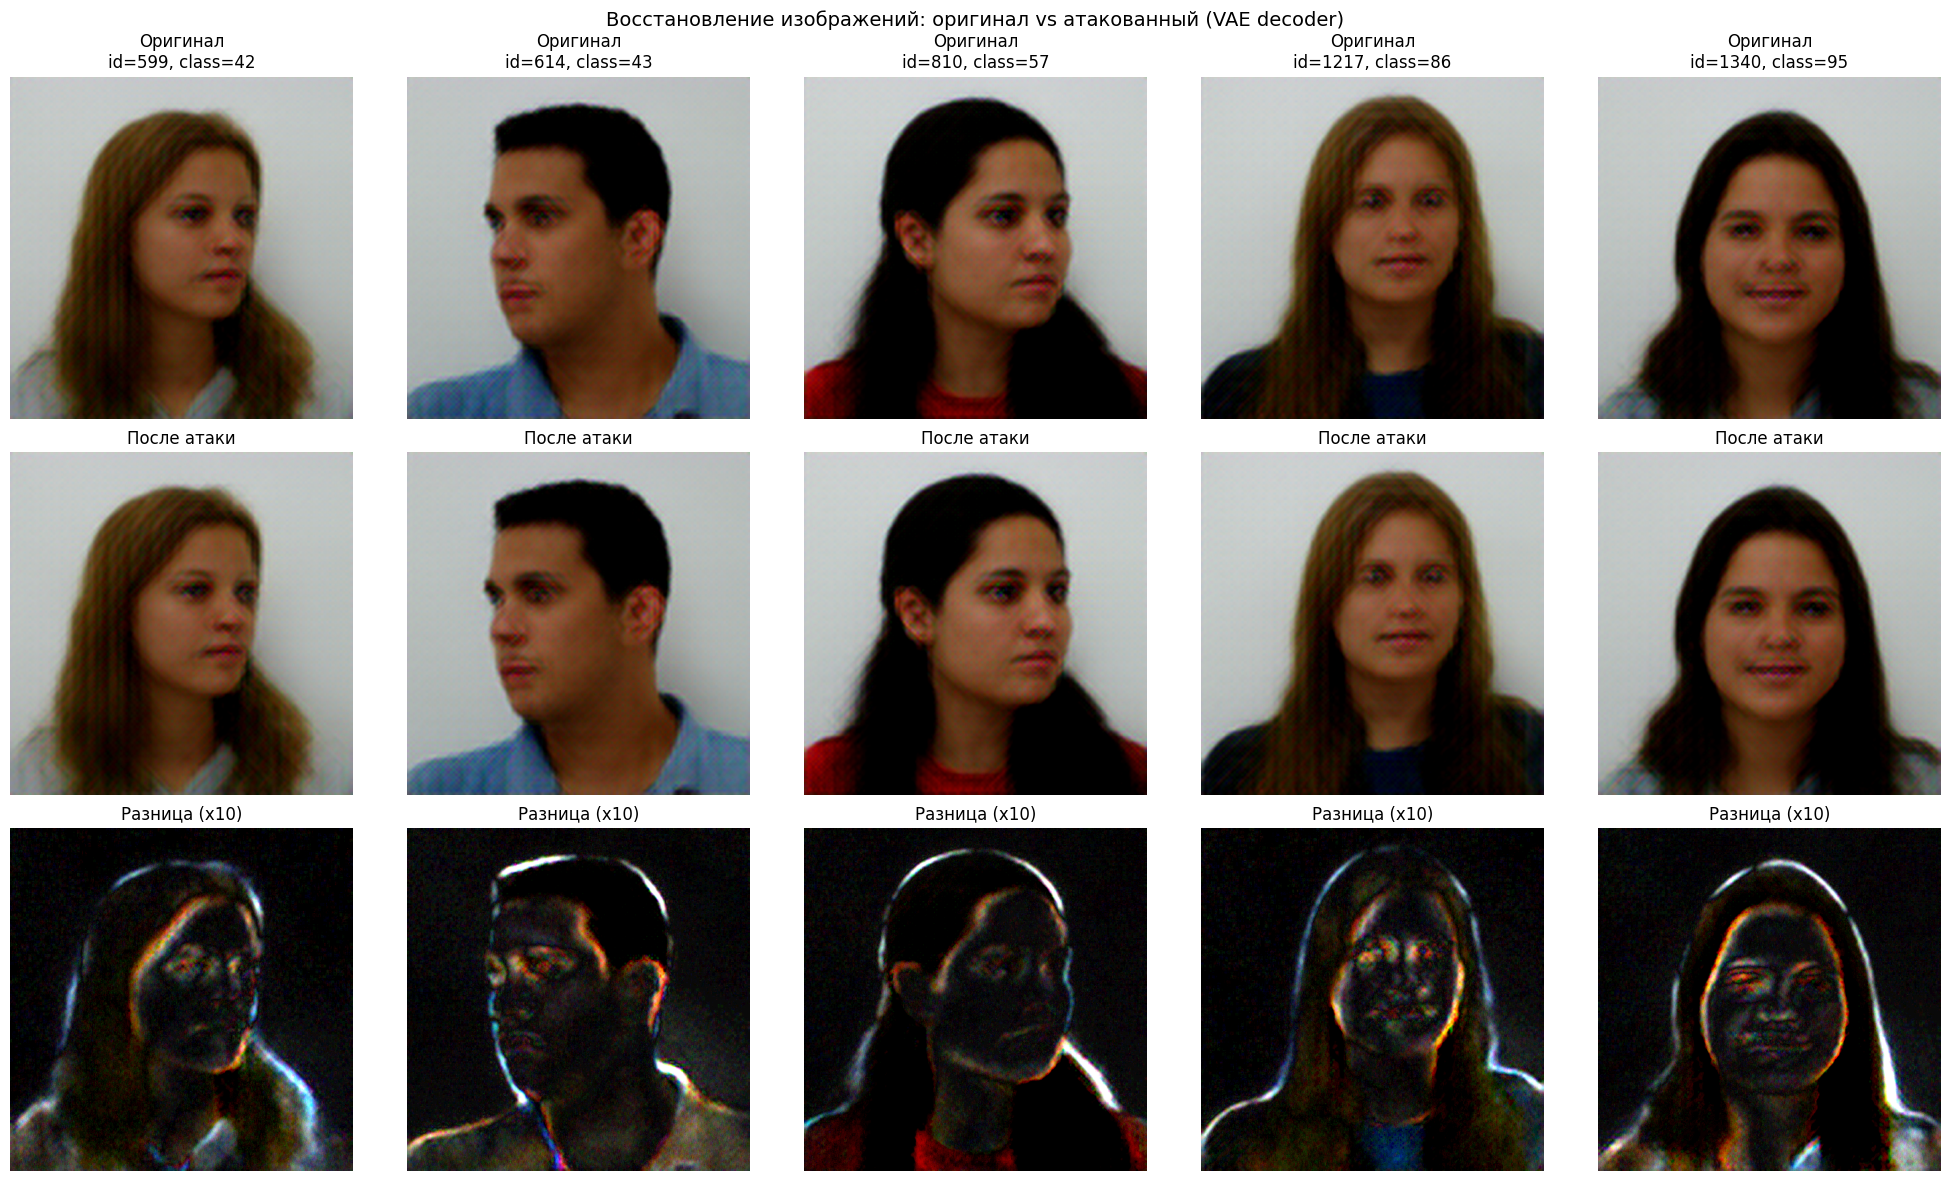

In [10]:
# Визуализация: оригинал vs атакованный
n = len(pairs)
fig, axes = plt.subplots(3, n, figsize=(4 * n, 12))

for i, pair in enumerate(pairs):
    img_orig = decode_and_enhance(model, pair['orig'], device)
    img_adv = decode_and_enhance(model, pair['adv'], device)
    
    # Разница (усиленная для видимости)
    diff = np.abs(img_adv - img_orig)
    diff_amplified = np.clip(diff * 10, 0, 1)
    
    # Оригинал
    axes[0, i].imshow(img_orig)
    axes[0, i].set_title(f'Оригинал\nid={pair["id"]}, class={pair["class"]}')
    axes[0, i].axis('off')
    
    # Атакованный
    axes[1, i].imshow(img_adv)
    axes[1, i].set_title(f'После атаки')
    axes[1, i].axis('off')
    
    # Разница
    axes[2, i].imshow(diff_amplified)
    axes[2, i].set_title(f'Разница (x10)')
    axes[2, i].axis('off')

plt.suptitle('Восстановление изображений: оригинал vs атакованный (VAE decoder)', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Статистика по попиксельной разнице
print('=' * 70)
print('СТАТИСТИКА ПО ПОПИКСЕЛЬНОЙ РАЗНИЦЕ ИЗОБРАЖЕНИЙ:')
print('=' * 70)

for pair in pairs:
    img_orig = decode_and_enhance(model, pair['orig'], device)
    img_adv = decode_and_enhance(model, pair['adv'], device)
    diff = np.abs(img_adv - img_orig)
    
    # L2 расстояние между латентными векторами
    latent_l2 = np.linalg.norm(pair['adv'] - pair['orig'])
    
    print(f'\nОбразец id={pair["id"]}, class={pair["class"]}:')
    print(f'  L2 расстояние в латентном пространстве: {latent_l2:.4f}')
    print(f'  Средняя попиксельная разница: {diff.mean():.6f}')
    print(f'  Максимальная попиксельная разница: {diff.max():.6f}')
    print(f'  SSIM-подобная метрика (1 - mean_diff): {1 - diff.mean():.4f}')

print('\n' + '=' * 70)

СТАТИСТИКА ПО ПОПИКСЕЛЬНОЙ РАЗНИЦЕ ИЗОБРАЖЕНИЙ:

Образец id=599, class=42:
  L2 расстояние в латентном пространстве: 36.1089
  Средняя попиксельная разница: 0.008500
  Максимальная попиксельная разница: 0.180392
  SSIM-подобная метрика (1 - mean_diff): 0.9915

Образец id=614, class=43:
  L2 расстояние в латентном пространстве: 40.5163
  Средняя попиксельная разница: 0.009547
  Максимальная попиксельная разница: 0.309804
  SSIM-подобная метрика (1 - mean_diff): 0.9905

Образец id=810, class=57:
  L2 расстояние в латентном пространстве: 36.3987
  Средняя попиксельная разница: 0.005997
  Максимальная попиксельная разница: 0.235294
  SSIM-подобная метрика (1 - mean_diff): 0.9940

Образец id=1217, class=86:
  L2 расстояние в латентном пространстве: 41.0777
  Средняя попиксельная разница: 0.007421
  Максимальная попиксельная разница: 0.184314
  SSIM-подобная метрика (1 - mean_diff): 0.9926

Образец id=1340, class=95:
  L2 расстояние в латентном пространстве: 40.3459
  Средняя попиксельная ра

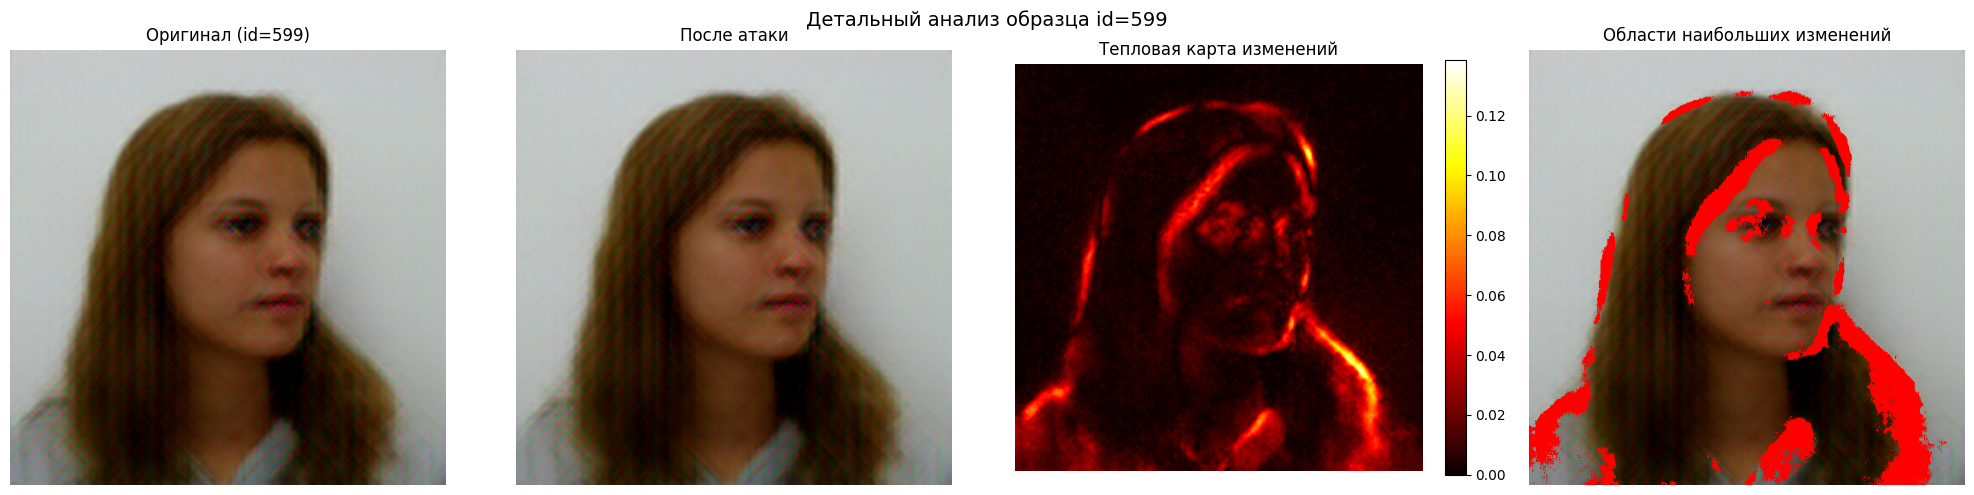

In [74]:
# Детальное сравнение одного образца
idx = 0  # индекс образца для детального сравнения
pair = pairs[idx]

img_orig = decode_and_enhance(model, pair['orig'], device)
img_adv = decode_and_enhance(model, pair['adv'], device)
diff = img_adv - img_orig

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_orig)
axes[0].set_title(f'Оригинал (id={pair["id"]})')
axes[0].axis('off')

axes[1].imshow(img_adv)
axes[1].set_title('После атаки')
axes[1].axis('off')

# Тепловая карта разницы
diff_gray = np.mean(np.abs(diff), axis=2)
im = axes[2].imshow(diff_gray, cmap='hot', vmin=0)
axes[2].set_title('Тепловая карта изменений')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

# Наложение разницы на оригинал
overlay = img_orig.copy()
mask = diff_gray > np.percentile(diff_gray, 90)
overlay[mask] = [1, 0, 0]  # красным выделяем области с наибольшими изменениями
axes[3].imshow(overlay)
axes[3].set_title('Области наибольших изменений')
axes[3].axis('off')

plt.suptitle(f'Детальный анализ образца id={pair["id"]}', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Сохранение результатов
output_dir = root / 'results' / 'decoded_images'
output_dir.mkdir(parents=True, exist_ok=True)

for pair in pairs:
    img_orig = decode_and_enhance(model, pair['orig'], device)
    img_adv = decode_and_enhance(model, pair['adv'], device)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(img_orig)
    axes[0].set_title(f'Оригинал')
    axes[0].axis('off')
    
    axes[1].imshow(img_adv)
    axes[1].set_title(f'После атаки')
    axes[1].axis('off')
    
    diff_gray = np.mean(np.abs(img_adv - img_orig), axis=2)
    axes[2].imshow(diff_gray, cmap='hot')
    axes[2].set_title(f'Карта изменений')
    axes[2].axis('off')
    
    plt.suptitle(f'id={pair["id"]}, class={pair["class"]}')
    plt.tight_layout()
    plt.savefig(output_dir / f'comparison_id{pair["id"]}.png', dpi=150, bbox_inches='tight')
    plt.savefig(output_dir / f'comparison_id{pair["id"]}.pdf', dpi=150, bbox_inches='tight')
    plt.close()

print(f'Все сравнения сохранены в: {output_dir}')

Все сравнения сохранены в: C:\Users\sukharev\Desktop\maga\diplom\NCT-research\PIPELINE\results\decoded_images
